#🏥 Healthcare Data Analysis
## SQL & Python Analysis using Google Colab
### Dataset: 5000 patients | Jan 2022 - Dec 2024 |


## 🗄️ SQLite Database Setup


In [ ]:

import sqlite3
df = pd.read_excel('healthcare_Analysis.xlsx',
                   sheet_name='Health_Care_Analysis')
print("Shape:", df.shape)

Shape: (5000, 25)


In [ ]:
conn = sqlite3.connect('healthcare.db')
df.to_sql('healthcare', conn, if_exists='replace', index=False)
print("Database created!")

Database created!


In [ ]:
def run_query(query):
    return pd.read_sql_query(query, conn)
print("run_query function ready!")

run_query function ready!


# 🔍  Exploratory Data Analysis (SQL)

In [ ]:
result = run_query("""
    PRAGMA table_info(healthcare)
""")
print(result)

    cid                        name       type  notnull dflt_value  pk
0     0                  Patient_ID       TEXT        0       None   0
1     1                         Age    INTEGER        0       None   0
2     2                      Gender       TEXT        0       None   0
3     3                 Blood_Group       TEXT        0       None   0
4     4                       State       TEXT        0       None   0
5     5                    Hospital       TEXT        0       None   0
6     6                  Department       TEXT        0       None   0
7     7              Admission_Type       TEXT        0       None   0
8     8                   Diagnosis       TEXT        0       None   0
9     9                   Treatment       TEXT        0       None   0
10   10                  Admit_Date  TIMESTAMP        0       None   0
11   11              Discharge_Date  TIMESTAMP        0       None   0
12   12         Length_of_Stay_Days    INTEGER        0       None   0
13   1

In [ ]:
result = run_query("""
    SELECT
        SUM(CASE WHEN Patient_ID IS NULL THEN 1 ELSE 0 END) as Null_PatientID,
        SUM(CASE WHEN Age IS NULL THEN 1 ELSE 0 END) as Null_Age,
        SUM(CASE WHEN Gender IS NULL THEN 1 ELSE 0 END) as Null_Gender,
        SUM(CASE WHEN Diagnosis IS NULL THEN 1 ELSE 0 END) as Null_Diagnosis
    FROM healthcare
""")
print(result)

   Null_PatientID  Null_Age  Null_Gender  Null_Diagnosis
0               0         0            0               0


In [ ]:
result = run_query("""
    SELECT
        MIN(Age) as Min_Age,
        MAX(Age) as Max_Age,
        ROUND(AVG(Age),2) as Avg_Age,
        MIN(Billing_Amount_INR) as Min_Billing,
        MAX(Billing_Amount_INR) as Max_Billing,
        ROUND(AVG(Billing_Amount_INR),2) as Avg_Billing
    FROM healthcare
""")
print(result)

   Min_Age  Max_Age  Avg_Age  Min_Billing  Max_Billing  Avg_Billing
0        1       94     51.0      1032.97    172597.67     18325.91


# 📊 Core Business Analysis (SQL)

In [ ]:
result = run_query("""
    SELECT Department,
        ROUND(SUM(Billing_Amount_INR),2) as Total_Billing,
        COUNT(*) as Total_Patients
    FROM healthcare
    GROUP BY Department
    ORDER BY Total_Billing DESC
""")
print(result)

         Department  Total_Billing  Total_Patients
0       Orthopedics    10135200.72             523
1  Gastroenterology     9669033.16             538
2         Neurology     9496440.04             528
3     Endocrinology     9222409.06             499
4        Cardiology     9086694.16             487
5       Dermatology     9039682.95             516
6          Oncology     8941213.78             481
7         Emergency     8742936.86             477
8        Pediatrics     8656828.90             488
9       Pulmonology     8639122.41             463


In [ ]:

result = run_query("""
    SELECT Diagnosis,
        COUNT(*) as Total_Patients
    FROM healthcare
    GROUP BY Diagnosis
    ORDER BY Total_Patients DESC
    LIMIT 10
""")
print(result)

             Diagnosis  Total_Patients
0               Asthma             190
1            Pneumonia             177
2             Migraine             118
3                 Acne             116
4      Spinal Stenosis             115
5        Ear Infection             112
6      Type 1 Diabetes             111
7               Stroke             111
8               Eczema             111
9  Parkinson's Disease             110


In [ ]:
result = run_query("""
    SELECT State,
        COUNT(*) as Total_Patients,
        SUM(CASE WHEN ICU_Stay = 'Yes'
            THEN 1 ELSE 0 END) as ICU_Patients,
        ROUND(SUM(CASE WHEN ICU_Stay = 'Yes'
            THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2)
            as ICU_Rate_Percent
    FROM healthcare
    GROUP BY State
    ORDER BY ICU_Patients DESC
""")
print(result)

            State  Total_Patients  ICU_Patients  ICU_Rate_Percent
0       Telangana             488           110             22.54
1       Rajasthan             493           101             20.49
2         Gujarat             537           101             18.81
3  Andhra Pradesh             492            98             19.92
4       Karnataka             502            97             19.32
5     Maharashtra             485            90             18.56
6           Delhi             522            88             16.86
7      Tamil Nadu             482            84             17.43
8     West Bengal             509            83             16.31
9          Kerala             490            76             15.51


In [ ]:
result = run_query("""
    SELECT Department,
        COUNT(*) as Total_Patients,
        SUM(CASE WHEN Readmitted_Within_30Days = 'Yes'
            THEN 1 ELSE 0 END) as Readmissions,
        ROUND(SUM(CASE WHEN Readmitted_Within_30Days = 'Yes'
            THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2)
            as Readmission_Rate_Percent
    FROM healthcare
    GROUP BY Department
    ORDER BY Readmission_Rate_Percent DESC
""")
print(result)

         Department  Total_Patients  Readmissions  Readmission_Rate_Percent
0         Neurology             528            85                     16.10
1       Pulmonology             463            74                     15.98
2  Gastroenterology             538            84                     15.61
3        Cardiology             487            75                     15.40
4        Pediatrics             488            75                     15.37
5     Endocrinology             499            76                     15.23
6         Emergency             477            72                     15.09
7       Dermatology             516            73                     14.15
8          Oncology             481            68                     14.14
9       Orthopedics             523            71                     13.58


In [ ]:

result = run_query("""
    SELECT Department,
        ROUND(AVG(Patient_Satisfaction_Score), 2)
            as Avg_Satisfaction,
        COUNT(*) as Total_Patients
    FROM healthcare
    GROUP BY Department
    ORDER BY Avg_Satisfaction DESC
""")
print(result)

         Department  Avg_Satisfaction  Total_Patients
0          Oncology              3.88             481
1       Dermatology              3.87             516
2         Emergency              3.84             477
3        Cardiology              3.82             487
4         Neurology              3.78             528
5        Pediatrics              3.73             488
6     Endocrinology              3.73             499
7       Orthopedics              3.72             523
8       Pulmonology              3.70             463
9  Gastroenterology              3.67             538


## 🔥 Advanced SQL Queries
### Window Functions | CTEs | Subqueries

In [ ]:
result = run_query("""
    SELECT Department,
        ROUND(SUM(Billing_Amount_INR),2) as Total_Billing,
        RANK() OVER (ORDER BY SUM(Billing_Amount_INR)
        DESC) as Revenue_Rank
    FROM healthcare
    GROUP BY Department
""")
print(result)

         Department  Total_Billing  Revenue_Rank
0       Orthopedics    10135200.72             1
1  Gastroenterology     9669033.16             2
2         Neurology     9496440.04             3
3     Endocrinology     9222409.06             4
4        Cardiology     9086694.16             5
5       Dermatology     9039682.95             6
6          Oncology     8941213.78             7
7         Emergency     8742936.86             8
8        Pediatrics     8656828.90             9
9       Pulmonology     8639122.41            10


In [ ]:
result = run_query("""
    WITH High_Billing AS (
        SELECT *
        FROM healthcare
        WHERE Billing_Amount_INR > (
            SELECT AVG(Billing_Amount_INR)
            FROM healthcare
        )
    )
    SELECT Department,
        COUNT(*) as High_Value_Patients,
        ROUND(AVG(Billing_Amount_INR),2) as Avg_Billing
    FROM High_Billing
    GROUP BY Department
    ORDER BY High_Value_Patients DESC
""")
print(result)

         Department  High_Value_Patients  Avg_Billing
0       Orthopedics                  194     36191.20
1     Endocrinology                  181     33407.86
2         Neurology                  177     35074.73
3         Emergency                  170     33533.46
4          Oncology                  166     34588.82
5        Pediatrics                  164     34516.23
6  Gastroenterology                  164     36788.09
7        Cardiology                  164     36542.83
8       Dermatology                  163     34789.86
9       Pulmonology                  160     35592.16


In [ ]:
result = run_query("""
    SELECT Patient_ID, Department,
        Diagnosis,
        ROUND(Billing_Amount_INR,2) as Billing
    FROM healthcare
    WHERE Billing_Amount_INR > (
        SELECT AVG(Billing_Amount_INR)
        FROM healthcare
    )
    ORDER BY Billing_Amount_INR DESC
    LIMIT 10
""")
print(result)

  Patient_ID        Department        Diagnosis    Billing
0   PAT04145         Emergency         Overdose  172597.67
1   PAT03670          Oncology  Prostate Cancer  170662.85
2   PAT01139  Gastroenterology              IBS  166779.91
3   PAT01035  Gastroenterology     Peptic Ulcer  165480.60
4   PAT00942       Orthopedics         Fracture  163870.10
5   PAT01714     Endocrinology  Hyperthyroidism  159683.56
6   PAT03177          Oncology    Breast Cancer  155185.99
7   PAT01523          Oncology         Leukemia  143509.86
8   PAT04163       Dermatology           Eczema  143356.90
9   PAT02414  Gastroenterology  Crohn's Disease  139754.18


# Python EDA & Visualizations


In [ ]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("Blues_r")

print("Libraries loaded!")

Libraries loaded!


/tmp/ipykernel_3763/1244951326.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=billing, x='Total_Billing_M',
/tmp/ipykernel_3763/1244951326.py:17: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3763/1244951326.py:18: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.savefig('chart1_billing_dept.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


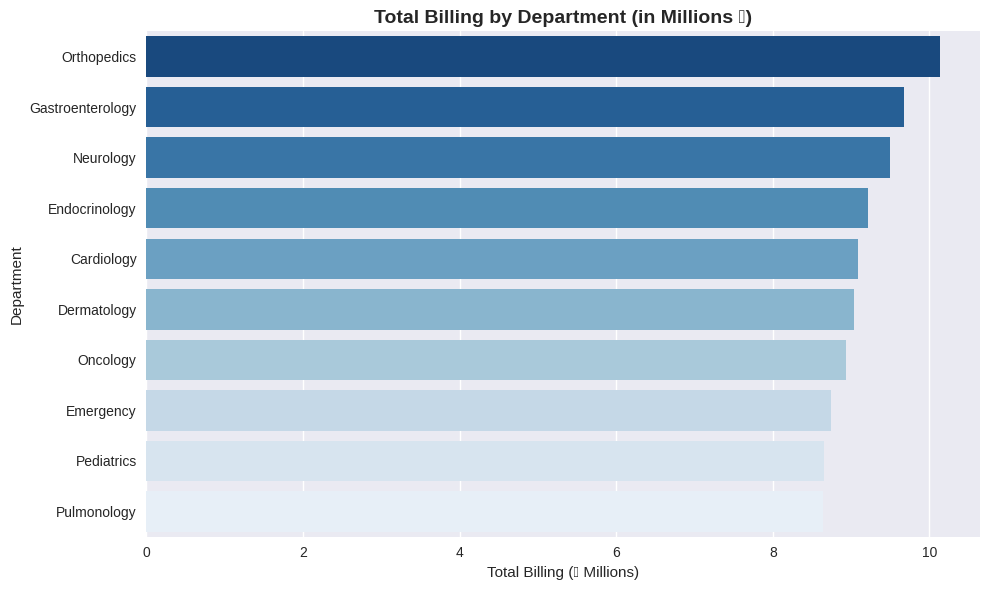

Chart 1 saved!


In [ ]:
billing = run_query("""
    SELECT Department,
        ROUND(SUM(Billing_Amount_INR)/1000000, 2)
        as Total_Billing_M
    FROM healthcare
    GROUP BY Department
    ORDER BY Total_Billing_M DESC
""")

plt.figure(figsize=(10, 6))
sns.barplot(data=billing, x='Total_Billing_M',
            y='Department', palette='Blues_r')
plt.title('Total Billing by Department (in Millions ₹)',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Billing (Millions)')
plt.ylabel('Department')
plt.tight_layout()
plt.savefig('chart1_billing_dept.png', dpi=150)
plt.show()
print("Chart 1 saved!")

### Total Billing by Department:
 This chart displays the total revenue generated by each hospital department,prominently featuring Orthopedics  and Gastroenterology as the highest

/tmp/ipykernel_3763/2737089364.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=diagnoses, x='Total_Patients',


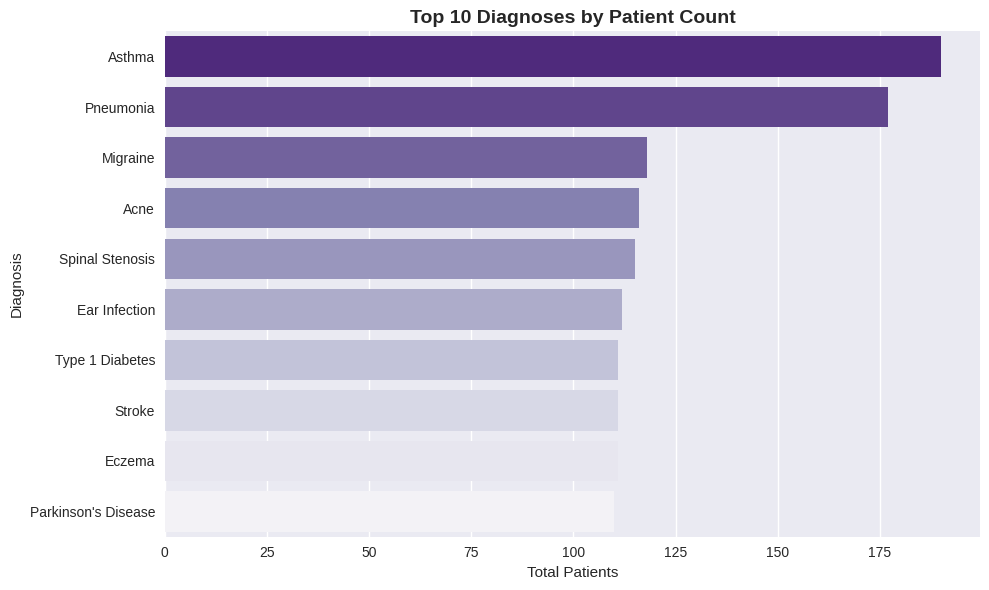

Chart 2 saved!


In [ ]:
diagnoses = run_query("""
    SELECT Diagnosis,
        COUNT(*) as Total_Patients
    FROM healthcare
    GROUP BY Diagnosis
    ORDER BY Total_Patients DESC
    LIMIT 10
""")

plt.figure(figsize=(10, 6))
sns.barplot(data=diagnoses, x='Total_Patients',
            y='Diagnosis', palette='Purples_r')
plt.title('Top 10 Diagnoses by Patient Count',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Patients')
plt.ylabel('Diagnosis')
plt.tight_layout()
plt.savefig('chart2_top10_diagnosis.png', dpi=150)
plt.show()
print("Chart 2 saved!")

### Top 10 Diagnoses:
 This chart identifies the ten most common diagnoses, prominently featuring Asthma and Pneumonia as the highest.

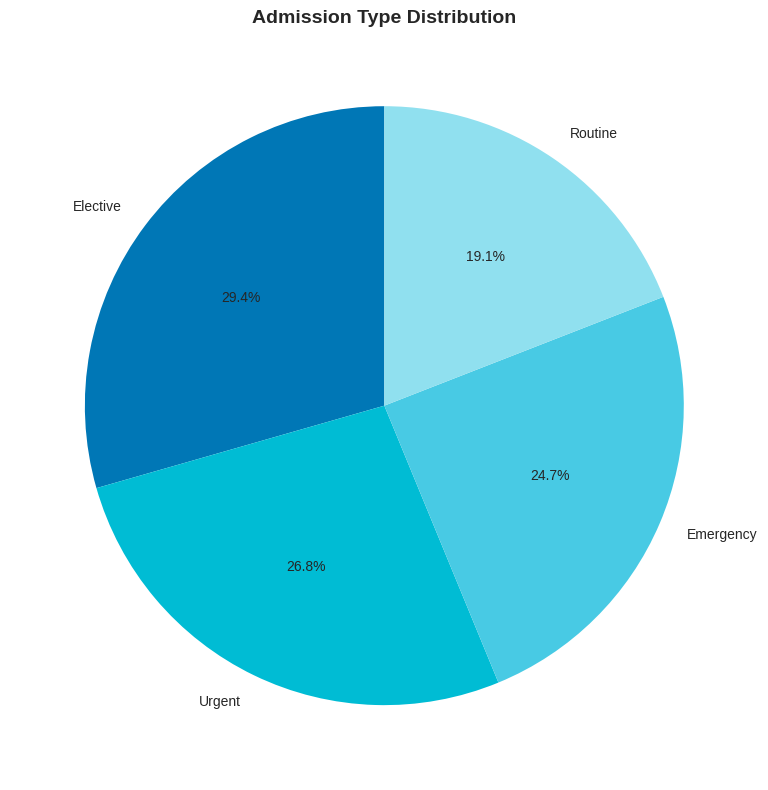

Chart 3 saved!


In [ ]:
admission = run_query("""
    SELECT Admission_Type,
        COUNT(*) as Total_Patients
    FROM healthcare
    GROUP BY Admission_Type
    ORDER BY Total_Patients DESC
""")

colors = ['#0077b6', '#00bcd4', '#48cae4', '#90e0ef']

plt.figure(figsize=(8, 8))
plt.pie(admission['Total_Patients'],
        labels=admission['Admission_Type'],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90)
plt.title('Admission Type Distribution',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_admission_type.png', dpi=150)
plt.show()
print("Chart 3 saved!")

### Patient Admission Types:
 This chart illustrates the distribution of admission types, with 'Emergency' admissions being the most frequent.

/tmp/ipykernel_3763/970474626.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=icu_state, x='ICU_Patients',


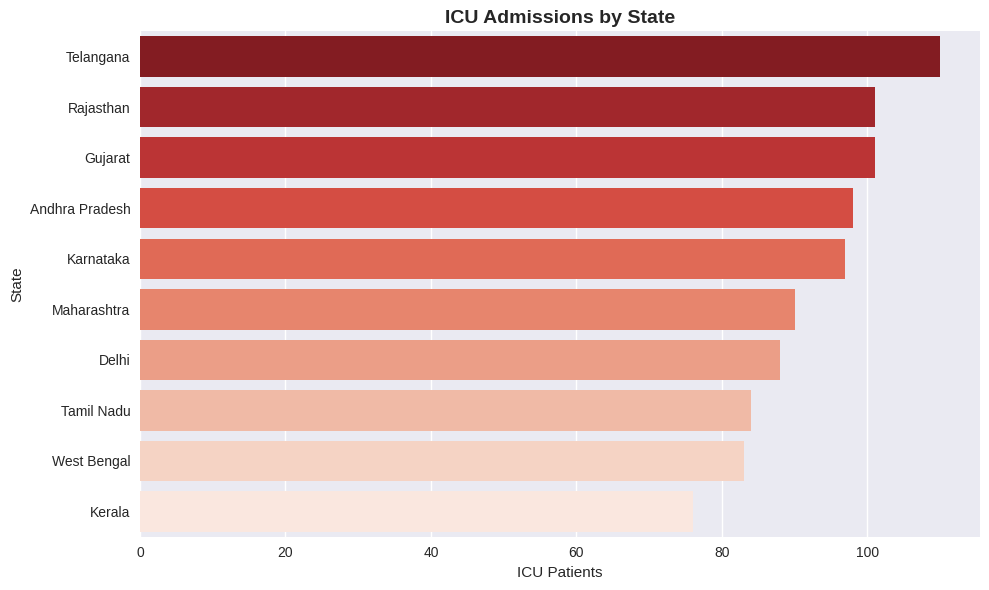

Chart 4 saved!


In [ ]:
icu_state = run_query("""
    SELECT State,
        SUM(CASE WHEN ICU_Stay = 'Yes'
            THEN 1 ELSE 0 END) as ICU_Patients
    FROM healthcare
    GROUP BY State
    ORDER BY ICU_Patients DESC
""")

plt.figure(figsize=(10, 6))
sns.barplot(data=icu_state, x='ICU_Patients',
            y='State', palette='Reds_r')
plt.title('ICU Admissions by State',
          fontsize=14, fontweight='bold')
plt.xlabel('ICU Patients')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('chart4_icu_state.png', dpi=150)
plt.show()
print("Chart 4 saved!")

### ICU Admissions by State:
 This chart displays the number of ICU patients per state, showing Telangana with the highest count.

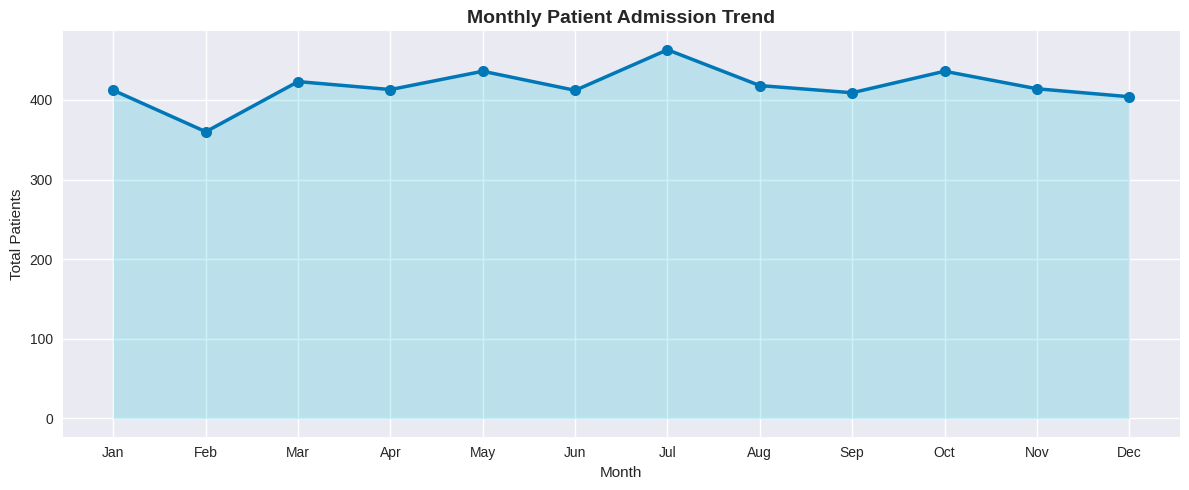

Chart 5 saved!


In [ ]:
monthly = run_query("""
    SELECT
        strftime('%m', Admit_Date) as Month_Num,
        COUNT(*) as Total_Patients
    FROM healthcare
    GROUP BY Month_Num
    ORDER BY Month_Num
""")

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
plt.plot(month_names, monthly['Total_Patients'],
         marker='o', color='#0077b6', linewidth=2.5,
         markersize=8)
plt.fill_between(range(12), monthly['Total_Patients'],
                 alpha=0.2, color='#00bcd4')
plt.title('Monthly Patient Admission Trend',
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Patients')
plt.xticks(range(12), month_names)
plt.tight_layout()
plt.savefig('chart5_monthly_trend.png', dpi=150)
plt.show()
print("Chart 5 saved!")

### Monthly Patient Admissions:
 This chart tracks the trend of patient admissions over different months, revealing seasonal variations.

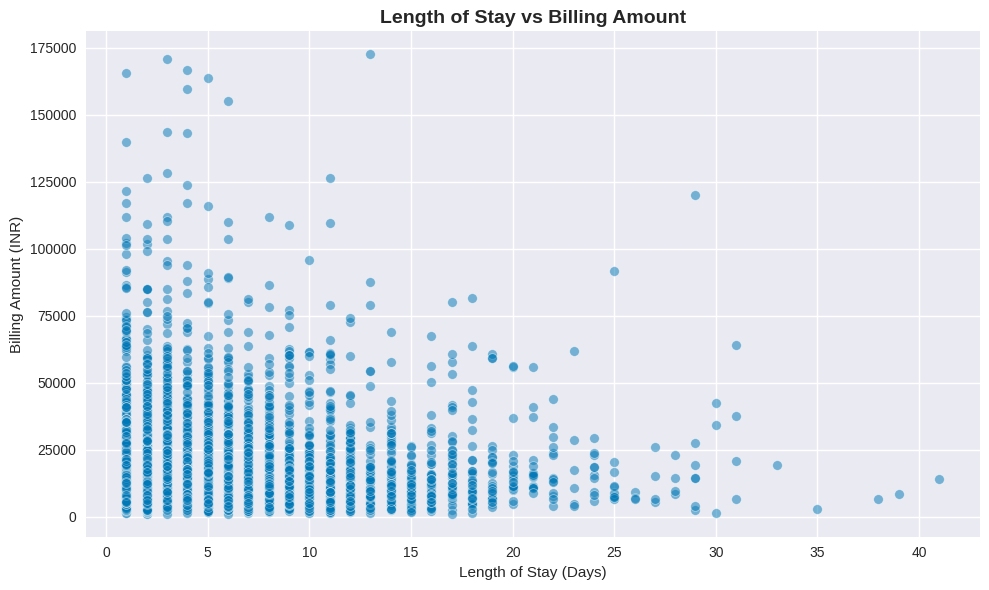

Chart 6 saved!


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,
    x='Length_of_Stay_Days',
    y='Billing_Amount_INR',
    alpha=0.5, color='#0077b6')
plt.title('Length of Stay vs Billing Amount',
    fontsize=14, fontweight='bold')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Billing Amount (INR)')
plt.tight_layout()
plt.savefig('chart6_stay_vs_billing.png', dpi=150)
plt.show()
print("Chart 6 saved!")

### Length of Stay vs. Billing:
 This scatter plot explores the relationship between hospital stay duration and billing amount, indicating no strong linear correlation.

/tmp/ipykernel_3763/2727221699.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ICU_Stay',


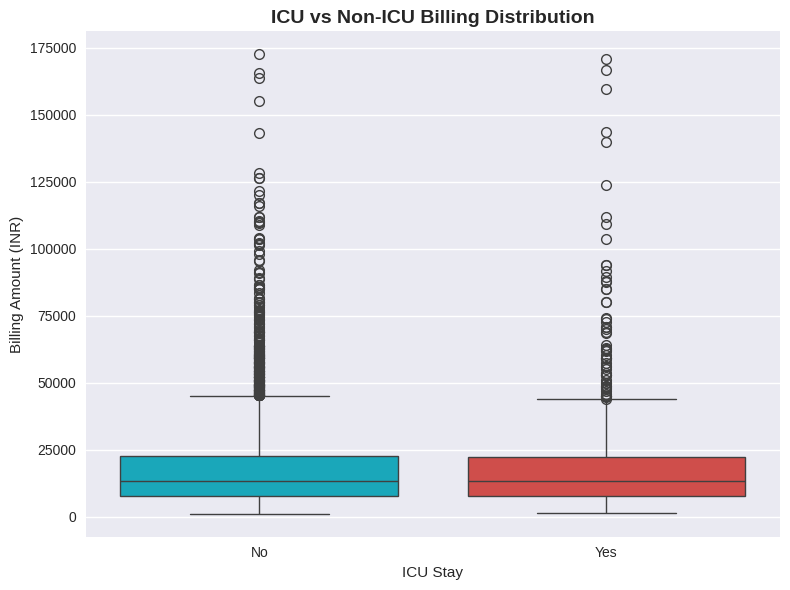

Chart 7 saved!


In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='ICU_Stay',
            y='Billing_Amount_INR',
            palette=['#00bcd4','#e53935'])
plt.title('ICU vs Non-ICU Billing Distribution',
          fontsize=14, fontweight='bold')
plt.xlabel('ICU Stay')
plt.ylabel('Billing Amount (INR)')
plt.tight_layout()
plt.savefig('chart7_icu_billing.png', dpi=150)
plt.show()
print("Chart 7 saved!")

### ICU vs. Non-ICU Billing:
This box plot compares billing amounts for ICU and non-ICU patients, showing significantly higher costs for ICU stays.

## 📊 Correlation Analysis

Let's explore the relationships between key numerical variables using a correlation matrix.

In [ ]:
import pandas as pd

# Ensure df is loaded in case of kernel restart or out-of-order execution
if 'df' not in locals():
    print("DataFrame 'df' not found. Reloading from source.")
    df = pd.read_excel('healthcare_Analysis.xlsx', sheet_name='Health_Care_Analysis')
    print("Shape:", df.shape)
else:
    print("DataFrame 'df' already loaded.")

DataFrame 'df' not found. Reloading from source.
Shape: (5000, 25)


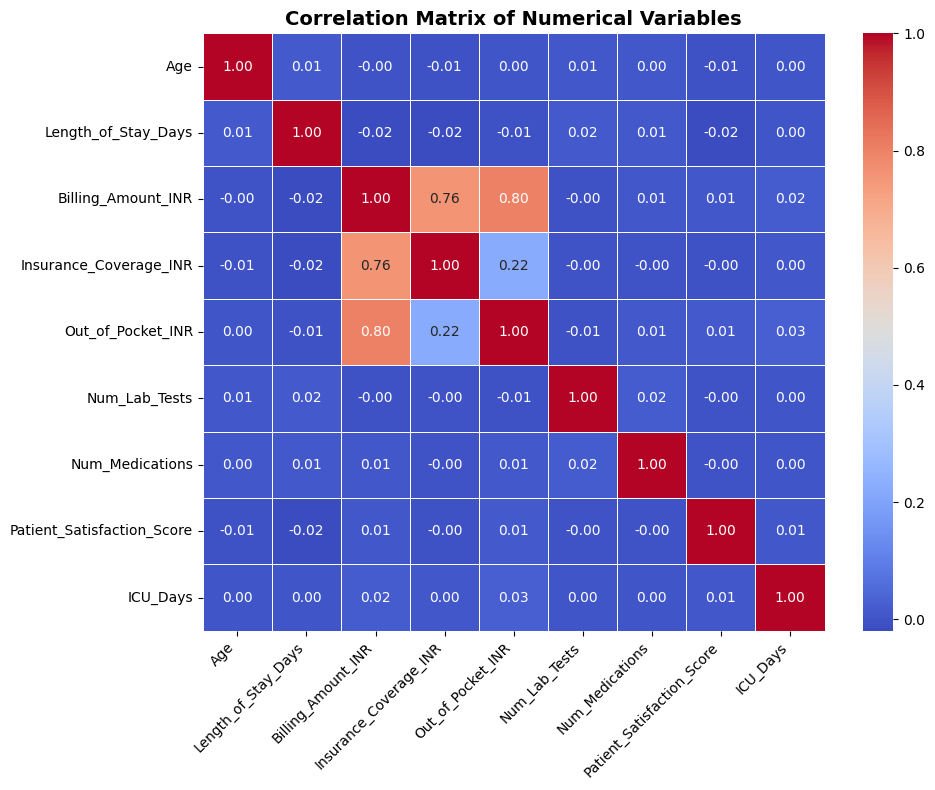

Chart 8 saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

numerical_cols = [
    'Age',
    'Length_of_Stay_Days',
    'Billing_Amount_INR',
    'Insurance_Coverage_INR',
    'Out_of_Pocket_INR',
    'Num_Lab_Tests',
    'Num_Medications',
    'Patient_Satisfaction_Score',
    'ICU_Days'
]

# Calculate the correlation matrix
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5
)
plt.title('Correlation Matrix of Numerical Variables', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('chart8_correlation_matrix.png', dpi=150)
plt.show()

print("Chart 8 saved!")

## 📊 Correlation Analysis:
This heatmap visualizes the correlation coefficients between numerical variables, highlighting the strongest relationships.

### 1. 💰 Revenue Insight
Orthopedics generates the highest revenue (₹10.1M, Rank 1),
suggesting complex surgical procedures drive billing.

### 2. 🏥 ICU Insight
Telangana has highest ICU admissions (110 cases, 22.54%),
indicating higher critical care demand in that region.
ICU patients generate ₹17.19M vs Non-ICU ₹74.43M —
but ICU cost per patient is significantly higher.

### 3. 🔄 Readmission Insight
Neurology has highest readmission rate (16.10%),
likely due to chronic neurological conditions
requiring repeated hospital visits.

### 4. 🩺 Diagnosis Insight
Asthma (190 cases) and Pneumonia (177 cases) are
most common — both respiratory conditions,
suggesting respiratory care is a major focus area.

### 5. ⭐ Satisfaction Insight
Oncology has highest satisfaction (3.88/5) despite
being a critical department — showing strong
patient care quality.

### 6. 📅 Stay vs Billing Insight
Longer hospital stays do NOT always mean higher
billing — treatment type is a stronger cost driver
than duration of stay.

### 7. 💊 High Value Patients
Orthopedics handles most above-average billing
patients (194 cases) — confirming it as the
highest-value department.